# Methodology Step 1 Implementation Breakdown

Part 1: Setup and Load Dataset

In [ ]:
import pandas as pd


df = pd.read_csv('dataset.csv')

# Preview the dataset
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,1/1/2019 0:00,2.703190e+15,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",3/9/1988,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,1/1/2019 0:00,6.304230e+11,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,6/21/1978,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,1/1/2019 0:00,3.885950e+13,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1/19/1962,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,1/1/2019 0:01,3.534090e+15,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1/12/1967,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,1/1/2019 0:03,3.755340e+14,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,3/28/1986,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


Part 2: Simulate Bank-wise Data Split (Federated Setup)

We simulate multiple banks (clients) having their own datasets. Each bank never shares raw data.

Each subset mimics independent, privacy-respecting institutions.

In [ ]:

# Simulate data split between 3 banks
from sklearn.model_selection import train_test_split

# Split data for federated learning (3 banks)
bank1, temp = train_test_split(df, test_size=0.66, random_state=42)
bank2, bank3 = train_test_split(temp, test_size=0.5, random_state=42)

# Check number of records
print(f"Bank 1 records: {len(bank1)}")
print(f"Bank 2 records: {len(bank2)}")
print(f"Bank 3 records: {len(bank3)}")


Bank 1 records: 356515
Bank 2 records: 346030
Bank 3 records: 346030


Part 3: Preprocessing Each Bank’s Data Locally

In federated learning, preprocessing happens locally per client.

In [ ]:
from sklearn.preprocessing import StandardScaler

def preprocess(data):
   
    labels = data['is_fraud']

    # Drop the target column for supervised learning
    features = data.drop('is_fraud', axis=1)

    # Keep only numeric columns (exclude strings like dates or IDs)
    numeric_features = features.select_dtypes(include=['int64', 'float64'])

    # Scale numeric features
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(numeric_features)

    return features_scaled, labels


Part 4: Outline the Federated Learning Setup

Here, instead of training centrally, we simulate each bank training locally and then sharing encrypted gradients.

In [ ]:

print("""
Federated Learning Overview:
- Each bank trains a local model using its private data.
- Banks do not share their actual data.
- Only encrypted gradients (via homomorphic encryption) or model weights are sent to the server.
- Server aggregates them to update a global model.
""")



Federated Learning Overview:
- Each bank trains a local model using its private data.
- Banks do not share their actual data.
- Only encrypted gradients (via homomorphic encryption) or model weights are sent to the server.
- Server aggregates them to update a global model.



# Step 2: Federated Model Training Simulation

In this step, I simulate how each bank (client) trains its local model, and how a central server aggregates the model updates — all without accessing the banks’ raw data.

Part 5: Define a Simple Neural Network for Each Bank

We'll use a small Deep Learning model (e.g., MLP) that each bank can train independently.

In [ ]:

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

def create_model(input_shape):
    model = Sequential([
        Dense(16, input_shape=(input_shape,), activation='relu'),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


Part 6: Local Training on Each Bank’s Data

Each bank trains its model locally, mimicking federated learning.

Preprocessing + Local Training (Run this together)

In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
import numpy as np


df = pd.read_csv('dataset.csv')

# Split dataset among 3 banks
bank1, temp = train_test_split(df, test_size=0.66, random_state=42)
bank2, bank3 = train_test_split(temp, test_size=0.5, random_state=42)

# Preprocessing function
def preprocess(data):
    labels = data['is_fraud']
    features = data.drop('is_fraud', axis=1)
    numeric_features = features.select_dtypes(include=['int64', 'float64'])
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(numeric_features)
    return features_scaled, labels

# Preprocess for all 3 banks
X1, y1 = preprocess(bank1)
X2, y2 = preprocess(bank2)
X3, y3 = preprocess(bank3)

# Create model function
def create_model(input_shape):
    model = Sequential([
        Dense(16, input_shape=(input_shape,), activation='relu'),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Create and train models for each bank
model1 = create_model(X1.shape[1])
model2 = create_model(X2.shape[1])
model3 = create_model(X3.shape[1])

# Train locally and capture training history
history1 = model1.fit(X1, y1, epochs=5, batch_size=32, verbose=1)
history2 = model2.fit(X2, y2, epochs=5, batch_size=32, verbose=1)
history3 = model3.fit(X3, y3, epochs=5, batch_size=32, verbose=1)



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
11142/11142 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - accuracy: 0.9750 - loss: 0.0725
Epoch 2/5
11142/11142 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.9943 - loss: 0.0235
Epoch 3/5
11142/11142 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step - accuracy: 0.9942 - loss: 0.0223
Epoch 4/5
11142/11142 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.9944 - loss: 0.0218
Epoch 5/5
11142/11142 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - accuracy: 0.9945 - loss: 0.0205
Epoch 1/5
10814/10814 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step - accuracy: 0.9852 - loss: 0.0603
Epoch 2/5
10814/10814 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - accuracy: 0.9941 - loss: 0.0243
Epoch 3/5
10814/10814 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - accuracy: 0.9942 - loss: 0.0229
Epoch 4/5
10814/10814 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - accuracy: 0.9942 - loss: 0.0229
Epoch 5/5
10814/10814 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - accuracy: 0.9943 - loss: 0.0220
Epoch 1/5
10814/10814 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.9885 - loss: 0.0513
Epoch 2/5


 Now Add Plotting Code for Loss & Accuracy

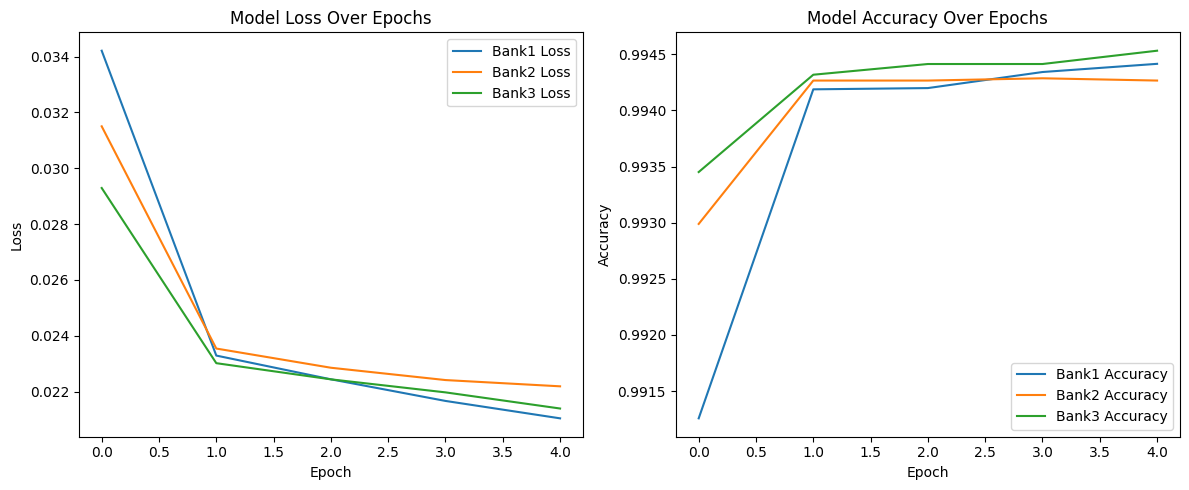

In [ ]:
import matplotlib.pyplot as plt

# Function to plot loss and accuracy
def plot_history(histories, labels):
    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    for history, label in zip(histories, labels):
        plt.plot(history.history['loss'], label=f'{label} Loss')
    plt.title('Model Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    for history, label in zip(histories, labels):
        plt.plot(history.history['accuracy'], label=f'{label} Accuracy')
    plt.title('Model Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()


plot_history([history1, history2, history3], ['Bank1', 'Bank2', 'Bank3'])


Part 7: Aggregate Model Weights (Simulated Global Model Update)

In federated learning, the server averages weights of all local models.

In [ ]:

import numpy as np

def average_weights(models):
    new_weights = []
    for weights in zip(*[model.get_weights() for model in models]):
        new_weights.append(np.mean(weights, axis=0))
    return new_weights


avg_weights = average_weights([model1, model2, model3])

# Apply to a global model
global_model = create_model(X1.shape[1])
global_model.set_weights(avg_weights)


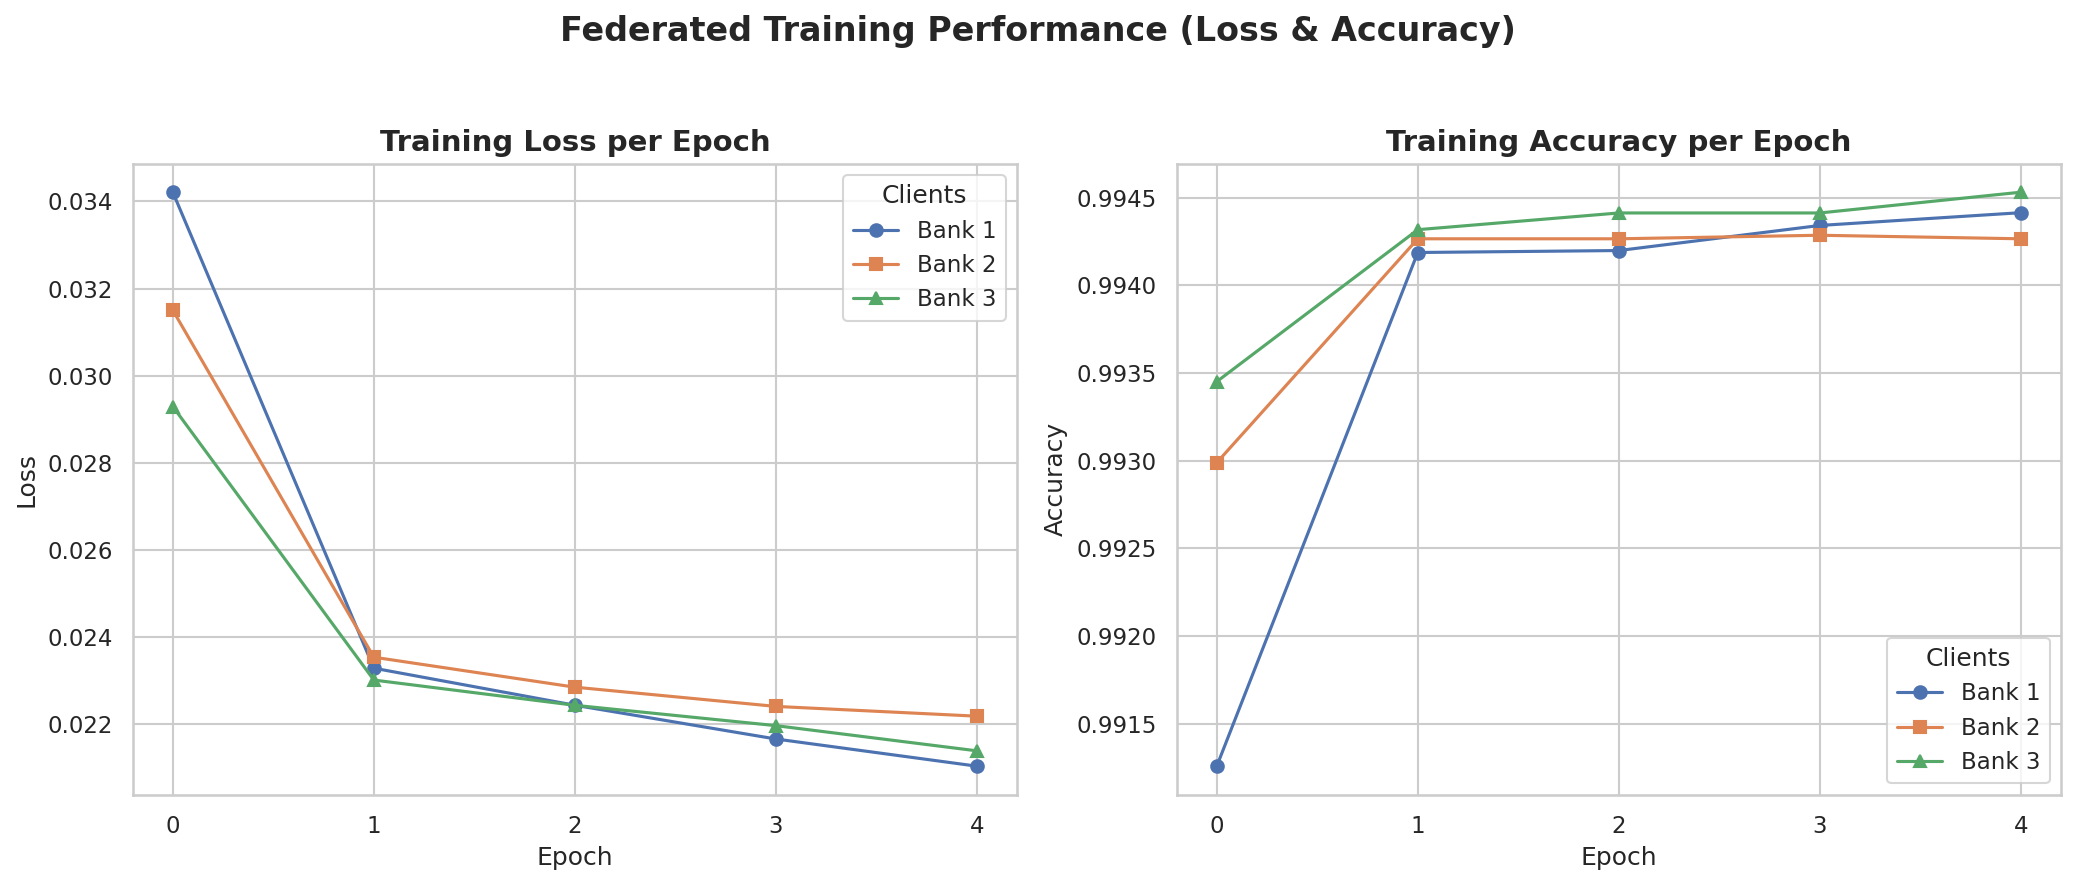

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style="whitegrid")
plt.figure(figsize=(14, 6), dpi=150)


plt.subplot(1, 2, 1)
plt.plot(history1.history['loss'], marker='o', label='Bank 1')
plt.plot(history2.history['loss'], marker='s', label='Bank 2')
plt.plot(history3.history['loss'], marker='^', label='Bank 3')
plt.title('Training Loss per Epoch', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(range(5))
plt.legend(title="Clients")
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(history1.history['accuracy'], marker='o', label='Bank 1')
plt.plot(history2.history['accuracy'], marker='s', label='Bank 2')
plt.plot(history3.history['accuracy'], marker='^', label='Bank 3')
plt.title('Training Accuracy per Epoch', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(range(5))
plt.legend(title="Clients")
plt.grid(True)


plt.suptitle('Federated Training Performance (Loss & Accuracy)', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
